# 🚀 Projet 2 : Requetez des services IA
### *Projet visant à apprendre à se servir d'un modèle IA déja entrainé à la segmentation vestimentaire*

## 1. Imports des bibliothèques

In [68]:
import os
import requests
from requests.exceptions import Timeout, HTTPError
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import base64
import io
from dotenv import load_dotenv


## 2. Récupération des variables d'environnement et création du header

In [69]:
# Charge le fichier .env
# En cas de changement de Var, utilisez override=True
load_dotenv(override=True)

# Récupération des variables de .env
api_token = os.getenv("API_KEY")
image_dir = os.getenv("IMAGE_DIR")
max_img = os.getenv("MAX_IMAGES")
api_url = os.getenv("API_URL")

# Content-Type sera créé au moment de l'appel de l'API
headers = {
    "Authorization": f"Bearer {api_token}",
}


image_paths = [
    image_dir + '/images_a_segmenter/image_0.png',
    image_dir + '/images_a_segmenter/image_1.png',
    image_dir + '/images_a_segmenter/image_2.png'
]

if not image_paths:
    print(f"Aucune image trouvée dans '{image_dir}'. Veuillez y ajouter des images.")
else:
    print(f"{len(image_paths)} image(s) à traiter : {image_paths}")


3 image(s) à traiter : ['./content/images_a_segmenter/image_0.png', './content/images_a_segmenter/image_1.png', './content/images_a_segmenter/image_2.png']


## 3. Paramétrage du masque

In [70]:

custom_colormap = {
    1: (0, 255, 255),   # Jaune - Hat
    2: (0, 165, 255),   # Orange - Hair
    3: (255, 0, 255),   # Magenta - Sunglasses
    4: (0, 0, 255),     # Rouge - Upper-clothes
    5: (255, 255, 0),   # Cyan - Skirt
    6: (0, 255, 0),     # Vert - Pants
    7: (255, 0, 0),     # Bleu - Dress
    8: (128, 0, 128),   # Violet - Belt
    9: (0, 255, 255),   # Jaune - Left-shoe
    10: (255, 140, 0),  # Orange foncé - Right-shoe
    11: (200, 180, 140), # Beige - Face
    12: (200, 180, 140), # Beige - Left-leg
    13: (200, 180, 140), # Beige - Right-leg
    14: (200, 180, 140), # Beige - Left-arm
    15: (200, 180, 140), # Beige - Right-arm
    16: (0, 128, 255),  # Bleu clair - Bag
    17: (255, 20, 147)  # Rose - Scarf
}

CLASS_MAPPING = {
    "Background": 0,
    "Hat": 1,
    "Hair": 2,
    "Sunglasses": 3,
    "Upper-clothes": 4,
    "Skirt": 5,
    "Pants": 6,
    "Dress": 7,
    "Belt": 8,
    "Left-shoe": 9,
    "Right-shoe": 10,
    "Face": 11,
    "Left-leg": 12,
    "Right-leg": 13,
    "Left-arm": 14,
    "Right-arm": 15,
    "Bag": 16,
    "Scarf": 17
}

## 4. Création des fonctions 
### 4.1 Pour les données du masque

In [71]:
def get_image_dimensions(img_path):
    """
    Get the dimensions of an image.

    Args:
        img_path (str): Path to the image.

    Returns:
        tuple: (width, height) of the image.
    """
    original_image = Image.open(img_path)
    return original_image.size

def decode_base64_mask(base64_string, width, height):
    """
    Decode a base64-encoded mask into a NumPy array.

    Args:
        base64_string (str): Base64-encoded mask.
        width (int): Target width.
        height (int): Target height.

    Returns:
        np.ndarray: Single-channel mask array.
    """
    mask_data = base64.b64decode(base64_string)
    mask_image = Image.open(io.BytesIO(mask_data))
    mask_array = np.array(mask_image)
    if len(mask_array.shape) == 3:
        mask_array = mask_array[:, :, 0]  # Take first channel if RGB
    mask_image = Image.fromarray(mask_array).resize((width, height), Image.NEAREST)
    return np.array(mask_image)

def create_masks(results, width, height):
    """
    Combine multiple class masks into a single segmentation mask.

    Args:
        results (list): List of dictionaries with 'label' and 'mask' keys.
        width (int): Target width.
        height (int): Target height.

    Returns:
        np.ndarray: Combined segmentation mask with class indices.
    """
    combined_mask = np.zeros((height, width), dtype=np.uint8)  # Initialize with Background (0)

    # Process non-Background masks first
    for result in results:
        label = result['label']
        class_id = CLASS_MAPPING.get(label, 0)
        if class_id == 0:  # Skip Background
            continue
        mask_array = decode_base64_mask(result['mask'], width, height)
        combined_mask[mask_array > 0] = class_id

    # Process Background last to ensure it doesn't overwrite other classes unnecessarily
    # (Though the model usually provides non-overlapping masks for distinct classes other than background)
    for result in results:
        if result['label'] == 'Background':
            mask_array = decode_base64_mask(result['mask'], width, height)
            # Apply background only where no other class has been assigned yet
            # This logic might need adjustment based on how the model defines 'Background'
            # For this model, it seems safer to just let non-background overwrite it first.
            # A simple application like this should be fine: if Background mask says pixel is BG, set it to 0.
            # However, a more robust way might be to only set to background if combined_mask is still 0 (initial value)
            combined_mask[mask_array > 0] = 0 # Class ID for Background is 0

    return combined_mask

### 4.2 Pour afficher le masque

In [72]:
def colorize_mask(mask, colormap):
    """
    Applique le colormap personnalisé au masque.
    Pour chaque pixel, s'il correspond à un label défini dans colormap,
    la couleur correspondante est assignée.
    """
    colored_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for label, color in colormap.items():
        colored_mask[mask == label] = color
    return colored_mask

def add_legend(image, legend, start_x=10, start_y=10, box_size=15, spacing=5):
    """
    Ajoute une légende sur l'image.
    Pour chaque label, dessine un rectangle de la couleur correspondante et le texte associé.
    """
    img_with_legend = image.copy()
    y = start_y
    for label, text in legend.items():
        # Récupération de la couleur du label
        color = custom_colormap.get(int(label), (255, 255, 255))
        # Dessin d'un petit rectangle rempli
        cv2.rectangle(img_with_legend, (start_x, y), (start_x + box_size, y + box_size), color, -1)
        # Ajout du texte à droite du rectangle
        cv2.putText(img_with_legend, text, (start_x + box_size + spacing, y + box_size - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
        y += box_size + spacing
    return img_with_legend

## 5. Requête API
Avant de traiter toutes les images, concentrons-nous sur une seule pour bien comprendre le processus.

Étapes :
1.  Choisir une image.
2.  Ouvrir l'image en mode binaire (`"rb"`) et lire son contenu (`data`).
3.  Déterminer le `Content-Type` (par exemple, `"image/jpeg"` ou `"image/png"`).
4.  Envoyer la requête POST à l'API avec `requests.post()` en passant l'URL, les headers et les données.
5.  Vérifier le code de statut de la réponse. Une erreur sera levée si le code n'est pas 2xx (succès) grâce à `response.raise_for_status()`.
6.  Convertir la réponse JSON en un dictionnaire Python avec `response.json()`.
7.  Utiliser nos fonctions `get_image_dimensions` et `create_masks` pour obtenir le masque final.
8.  Afficher l'image originale et le masque segmenté.

In [73]:
if image_paths:
    single_image_path = image_paths[0] # Prenons la première image de notre liste
    print(f"Traitement de l'image : {single_image_path}")
    

    # Test si les dimensions de l'image < 1024px
    img_dim = get_image_dimensions(single_image_path)
    if(max(img_dim) < 1024):
        try:
            # Lecture de l'image en binaire
            with open(single_image_path, "rb") as img:
                image_data = img.read()

            # Identification et test du Content-Type
            tmp_img = Image.open(io.BytesIO(image_data))
            if tmp_img.format in ("PNG", "JPG", "JPEG"):
                extension = "image/" + tmp_img.format
            
                headers["Content-Type"] = extension
            
                # Envoi de la requête
                response = requests.post(api_url, headers=headers, data=image_data)
                dic_response = response.json()
                print("Requête Ok")
            else:
                print("Le format {tmp_img.format} n'est pas pris en charge par l'API ")

        # Gère les exceptions de la requête POST
        # Timeout
        except Timeout:
            print("Erreur, le délai d'attente a été dépassé (Timeout)")

        # Trop de requête faite
        except HTTPError as http_err:
            status_code = http_err.response.status_code
            if status_code == 429:
                print("Limite atteinte : Trop de requêtes.")
                
        # Autre erreurs       
        except Exception as e:
            print(f"Une erreur est survenue : {e}")
else:
    print("Aucune image à traiter. Vérifiez la configuration de 'image_dir' et 'max_images'.")

Traitement de l'image : ./content/images_a_segmenter/image_0.png
Requête Ok


## 4. Visualisation du masque

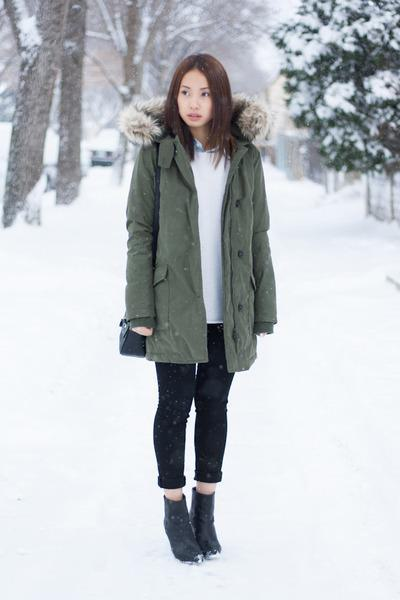

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(600, 400, 3), dtype=uint8)

In [74]:
mask = create_masks(dic_response,img_dim[0], img_dim[1])
mask_colorized = colorize_mask(mask, custom_colormap)
display(tmp_img)
display(mask_colorized)